# Data Processing with `geoPFA`: 2D Example from Newberry Volcano, OR
This tutorial demonstrates how to use the **data processing workflow** in `geoPFA`.  
You’ll learn how to:

1. Load a PFA configuration file (which defines criteria, components, and layers)
2. Read raw geospatial datasets into the working `pfa` dictionary
3. Process and clean these datasets onto a consistent grid ready for layer combination and favorability modeling

Subsequent notebooks will build upon this by combining layers, applying weights, and producing final favorability models.

## 1. Imports and Setup

In [5]:
# --- General imports ---
from pathlib import Path
import geopandas as gpd

# --- geoPFA core classes ---
from geopfa.io.data_readers import GeospatialDataReaders
from geopfa.io.data_writers import GeospatialDataWriters
from geopfa.processing import Cleaners, Processing
from geopfa.plotters import GeospatialDataPlotters

# --- Utilities ---
from geopfa.io.data_readers import safe_json_load
from geopfa.datasets import setup_newberry_tutorial_data

### Define Directories

In [6]:
# Get the directory where this notebook lives
notebook_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()

# Define the main project directory (where 'config/', 'data/', and 'notebooks/' live)
project_dir = notebook_dir.parent

# Define subdirectories
config_dir = project_dir / "config"
data_dir = project_dir / "data"

# Confirm structure
print("Notebook directory:", notebook_dir)
print("Config directory:", config_dir)
print("Data directory:", data_dir)

# Quick check before proceeding
for folder in [config_dir, data_dir]:
    if not folder.exists():
        raise FileNotFoundError(f"Expected folder not found: {folder}")

Notebook directory: c:\Users\smello\code\geoPFA\examples\Newberry\2D\notebooks
Config directory: c:\Users\smello\code\geoPFA\examples\Newberry\2D\config
Data directory: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data


### Download and extract example data
Here we use a built in function to download and extract the sample data for this tutorial to the necessary location

In [ ]:
setup_newberry_tutorial_data(data_dir)  # download exampel data to data directory defined above

Data extracted to: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data


## 2. Configuration and Data Input
With the project directories defined, the next step is to **read the configuration file** and **load all raw geospatial data** into memory.

Each PFA project is organized according to a hierarchy of criteria → components → layers, where each **layer** represents a dataset.  
![dir_structure](figs/pfa_processing.png)

The configuration JSON defines:
- Which layers belong to which components, and which components belong to which criteria
- Layer metadata including names, coordinate reference systems (CRS), and column definitions  
- Processing instructions (e.g., interpolation methods, z-measure units)

*Note: In this tutorial, the previous step automatically downloaded and structured the example dataset so that the /data directory already matches the expected layout.
However, understanding this structure is still essential when working with your own data or building new projects.*

To ensure a smooth workflow:
- The structure of the `/data` directory must exactly match those specified in the JSON (see example below). Folder names must match criteria and component names, and file names must match layer names.   
- Each dataset must have consistent column names and units with its config entry.
- See Configuration Instructions for more 

![dir_structure](figs/directory_structure.png)

### Read configuration file

In [8]:
# Path to configuration file
pfa_path = config_dir / "newberry_superhot_config.json"

# Load JSON configuration safely (handles comments and malformed JSON)
pfa = safe_json_load(pfa_path)

Successfully loaded JSON file from: c:\Users\smello\code\geoPFA\examples\Newberry\2D\config\newberry_superhot_config.json


### Load data into the `pfa` dictionary
The `gather_data` function scans the structured directories, matches files to layers defined in the configuration, and loads them into memory.

We enable validation to ensure that:
- all expected layers were found,
- data was successfully read,
- and datasets are not empty.

In [9]:
# Define the file types to be read (others will be skipped with a warning)
file_types = [".csv", ".shp"]

# Gather data according to the config structure
pfa = GeospatialDataReaders.gather_data(
    data_dir,
    pfa,
    file_types,
    validate=True
)

criteria: geologic
	 component: heat
		 reading layer: density_joint_inv
		 reading layer: mt_resistivity_joint_inv
		 reading layer: temperature_model_500m
		 reading layer: earthquakes
	 component: reservoir
		 reading layer: lineaments
		 reading layer: density_joint_inv
		 reading layer: mt_resistivity_joint_inv
		 reading layer: earthquakes
	 component: insulation
		 reading layer: density_joint_inv
		 reading layer: mt_resistivity_joint_inv
		 reading layer: earthquakes
		 reading layer: temperature_model_500m

All layers contain valid 'data'.


If any layers are missing or invalid, a summary will be printed. To enforce strict validation (raising an error instead of warnings), use: `validate=True`, `strict=True`

This validation step helps catch issues such as missing files, naming mismatches, or failed reads early in the workflow.

## 3. Harmonizing Data

Now that all raw layers are loaded into the `pfa` dictionary, we’ll:
- Define a target coordinate reference system (CRS)
- Constrain grid resolution (`nx` and `ny`)
- Import supporting data such as an area outline or a well path to give context
- Derive a shared spatial extent for clipping and gridding
- Preview the input data layers

### Define the Target CRS and Import Contextual Data

In [10]:
# EPSG code for UTM Zone 10N (meters)
target_crs = 26910
# Define grid resolution (number of cells in x and y)
nx = 300; ny = 300

# Load the project boundary shapefile
outline_path = data_dir / "supporting_data" / "national_monument_boundary" / "NNVM_bounds.shp"
outline = gpd.read_file(outline_path).to_crs(target_crs)

print(f"Loaded boundary: {outline_path.name}")

Loaded boundary: NNVM_bounds.shp


### Unify CRS and Define Extent
CRS is defined manually using the variable `target_crs` defined above. 
Extent is defined using the defined `extent_layer` above, where the project extent is set to that of the specified `extent_layer`.

In [11]:
# Reproject all layers to the target CRS
pfa = Cleaners.set_crs(pfa, target_crs=target_crs)

# Choose one representative layer to define the spatial extent
extent_layer = (
    pfa["criteria"]["geologic"]["components"]["heat"]["layers"]["mt_resistivity_joint_inv"]["data"]
)

# Get extent list. In 2D that is [xmin, ymin, xmax, ymax]
extent = Cleaners.get_extent(extent_layer, dim=2)  # Ensure we grab the 2d extent from 3d data

print(extent)

[624790.891073, 4825350.71118, 653145.891073, 4855310.71118]


## 4. Convert 3D Layers to 2D

Many datasets in a PFA project are generated or modeled in 3D, but 2D PFAs
often only require a surface representation.  
This step uses `Processing.convert_3d_to_2d()` to **collapse each 3D layer along the Z-dimension**
into a 2D `GeoDataFrame`. 
One could use `Processing.convert_3d_to_2d()` manually on each applicable data layer, but we use a for loop in this example as most data layers require flattening.

Instead of taking a slice at a given depth, this function sums over Z and each X,Y location, providing insight into thickness of features. If you'd prefer to use a slice at a given depth, use that 2D slice as your input data layer rather than inputting the 3D model.

Layers are only flattened if:
- They are marked as `"is_3d": "yes"` in the configuration file  
- They are **not** explicitly excluded (`"needs_flattening": "no"`)

To save time, each unique layer is flattened **only once** and then reused for any other component that references it.
This is especially useful for large shared datasets.


In [12]:
# Define the active criterion (geologic only in this example)
criteria = "geologic"

# Cache to store flattened layers and reuse them
flattened_layers = {}

for component, comp_data in pfa["criteria"][criteria]["components"].items():
    for layer, layer_config in comp_data["layers"].items():
        is_3d = layer_config.get("is_3d", None)
        needs_flattening = layer_config.get("needs_flattening", "yes")

        # Skip layers not flagged as 3D or marked "no" for flattening
        if not is_3d or str(needs_flattening).lower() == "no":
            continue

        # Use the layer name as the unique cache key
        key = layer

        if key in flattened_layers:
            print(f"Reusing flattened layer: {layer} for component: {component}")
            # Copy cached flattened layer into current component/layer
            pfa["criteria"][criteria]["components"][component]["layers"][layer] = (
                flattened_layers[key].copy()
            )
            continue

        print(f"Converting 3D layer: {layer} → 2D")

        # Perform flattening and store in PFA
        pfa = Processing.convert_3d_to_2d(pfa, criteria, component=component, layer=layer)

        # Cache the flattened result for reuse
        flattened_layers[key] = (
            pfa["criteria"][criteria]["components"][component]["layers"][layer].copy()
        )

print("3D → 2D flattening complete.")

Converting 3D layer: density_joint_inv → 2D
Converting 3D layer: mt_resistivity_joint_inv → 2D
Converting 3D layer: temperature_model_500m → 2D
Reusing flattened layer: density_joint_inv for component: reservoir
Reusing flattened layer: mt_resistivity_joint_inv for component: reservoir
Reusing flattened layer: density_joint_inv for component: insulation
Reusing flattened layer: mt_resistivity_joint_inv for component: insulation
Reusing flattened layer: temperature_model_500m for component: insulation
3D → 2D flattening complete.


### Visualize Cleaned Raw Data Layers
`geoPFA` has built-in plotting tools to help visualize data. Some examples are shown below using `GeospatialDataPlotters.quick_plot_layer`.
#### Plot a Single Layer

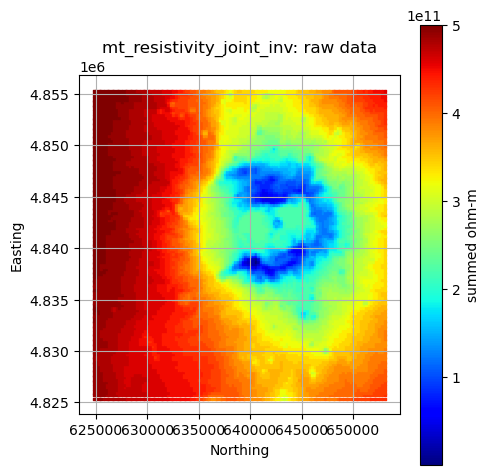

In [13]:
component = "heat"
layer = "mt_resistivity_joint_inv"

gdf = pfa["criteria"][criteria]["components"][component]["layers"][layer]["data"]  # the gdf data
col = pfa["criteria"][criteria]["components"][component]["layers"][layer]["data_col"]  # the gdf column of interest
units = pfa["criteria"][criteria]["components"][component]["layers"][layer]["units"]  # data units as specified by the config file
title = f"{layer}: raw data"

GeospatialDataPlotters.geo_plot(gdf, col, units, title, markersize=2, figsize=(5, 5))

#### Plot All Layers (Optional)

Loop through the full hierarchy and visualize every dataset.
This is useful for verifying that CRS, units, and extents align, but can take time for large inputs.

geologic
	heat


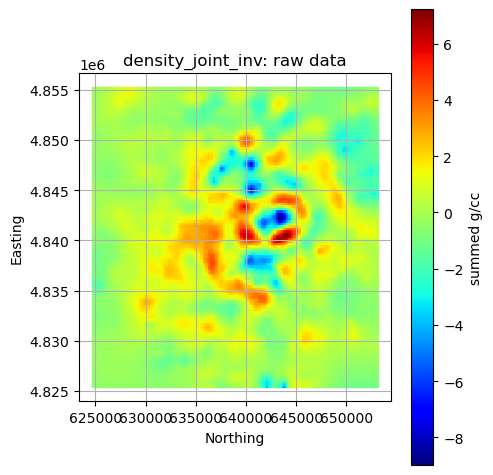

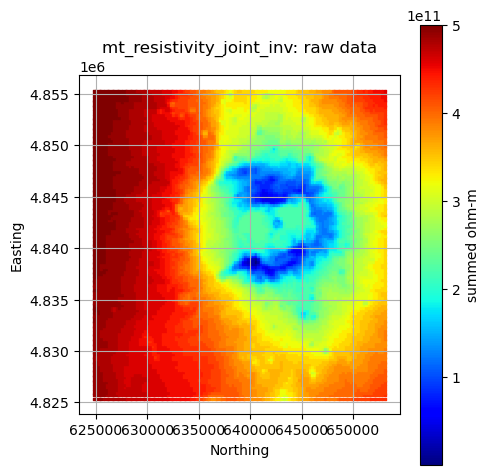

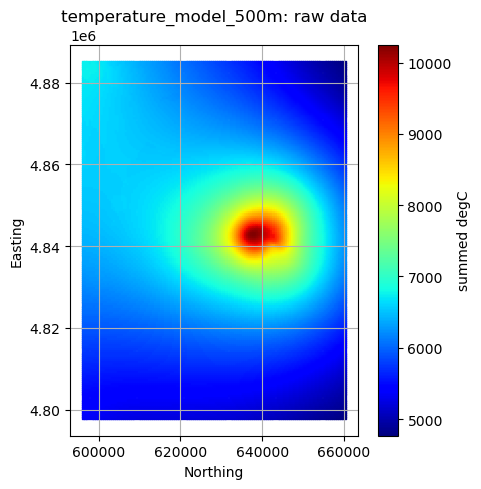

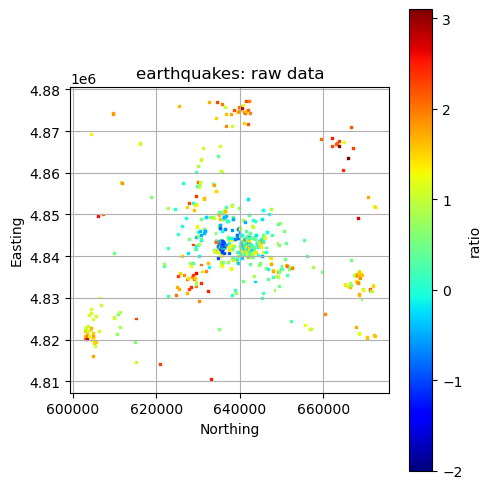

	reservoir
		density_joint_inv plotted already
		mt_resistivity_joint_inv plotted already
		earthquakes plotted already


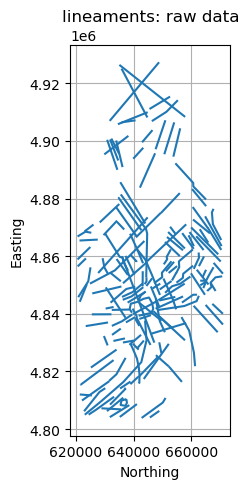

	insulation
		density_joint_inv plotted already
		mt_resistivity_joint_inv plotted already
		earthquakes plotted already
		temperature_model_500m plotted already


In [14]:
for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    plotted_layers = []
    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")
        for layer, layer_data in comp_data["layers"].items():
            if layer in plotted_layers:
                print(f"\t\t{layer} plotted already")
                continue

            gdf = layer_data["data"]
            col = layer_data.get("data_col", None)
            if layer == "faults_newberry":
                col = "None"  # faults are geometries only

            units = layer_data["units"]
            title = f"{layer}: raw data"

            GeospatialDataPlotters.geo_plot(gdf, col, units, title, markersize=2, figsize=(5, 5))
            plotted_layers.append(layer)

## 5. Data Processing and Preparation
This step transforms raw geospatial inputs into standardized layers on a shared 2D grid for comparison and combination.

Examples:
- *Permeability indicators*: distance to faults, earthquake density  
- *Heat indicators*: resistivity, temperature, low density  
- *Insulation indicators*: shallow resistivity, seismic velocity  

Processing ensures all layers:
- Are free from outliers  
- Share the same CRS and spatial extent  
- Are mapped to the same `(nx, ny)` grid  
- Represent continuous 2D evidence produced from the data layer (e.g. distance from faults as opposed to fault location)
---

### How It Works

All 2D `geoPFA` processing functions follow the same pattern:

1. Take the **raw input** stored in  
   `pfa["criteria"][criteria]["components"][component]["layers"][layer]["data"]`
2. Process it (e.g., interpolation, point density, distance-to-feature)  
   onto the common 2D grid
3. Write the result to  
   `pfa["criteria"][criteria]["components"][component]["layers"][layer]["model"]`

### Filter Outliers
Some datasets contain spurious extreme values.
Use Cleaners.filter_geodataframe() to remove these outliers based on a quantile threshold.

In [15]:
# Filter the upper 10% of values in selected datasets
target_layers = []

for layer in target_layers:
    for component in ["heat", "reservoir"]:
        gdf = pfa["criteria"][criteria]["components"]["heat"]["layers"][layer]["data"]
        col = pfa["criteria"][criteria]["components"]["heat"]["layers"][layer]["data_col"]

        filtered = Cleaners.filter_geodataframe(gdf, col, quantile=0.9)
        pfa["criteria"][criteria]["components"][component]["layers"][layer]["data"] = filtered

print("Outlier filtering complete.")

Outlier filtering complete.


### Extrapolation
`geoPFA` can perform extrapolation over each layer to ensure every layer fills the complete extent. `geoPFA` uses a sparse Gaussian process regression (GPR) model to backfill missing data. 

Extrapolation would naturally sit at this point in the processing workflow as it is a mechansim for placing data layers on a consistent grid, but we do not include an example here.  `geoPFA's` extrapolation feature is very powerful, but can be computationally expensive--working best with a careful understanding. For more information on this process and to see an example with data from the Newberry site, please refer to the `1.5-extrapolation_example.ipynb` notebook.

### Interpolation
For most datasets, data can be processed and prepared for layer combination and favorability estimation by simply interpolating data to the target grid. Here we do that only once for each input layer that has `"processing_method": "interpolate"` specified in the configuration file.

In [16]:
method = 'linear'

interpolated_layers = {}

for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")
        for layer, layer_config in comp_data["layers"].items():
            if layer_config.get("processing_method") == "interpolate":
                if layer in interpolated_layers:
                    print(f"\t\tReusing cached interpolation for {layer}")
                    pfa["criteria"][criteria]["components"][component]["layers"][layer]['model'] = (
                        interpolated_layers[layer]['model'].copy()
                    )
                    pfa["criteria"][criteria]["components"][component]["layers"][layer]['model_data_col'] = (
                        interpolated_layers[layer]['model_data_col']
                    )
                    pfa["criteria"][criteria]["components"][component]["layers"][layer]['model_units'] = (
                        interpolated_layers[layer]['model_units']
                    )
                else:
                    print(f"\t\tInterpolating layer: {layer}")
                    pfa = Processing.interpolate_points(
                        pfa,
                        criteria=criteria,
                        component=component,
                        layer=layer,
                        interp_method=method,
                        nx=nx,
                        ny=ny,
                        extent=extent,
                    )
                    interpolated_layers[layer] = (
                        pfa["criteria"][criteria]["components"][component]["layers"][layer].copy()
                    )


geologic
	heat
		Interpolating layer: density_joint_inv
		Interpolating layer: mt_resistivity_joint_inv
		Interpolating layer: temperature_model_500m
	reservoir
		Reusing cached interpolation for density_joint_inv
		Reusing cached interpolation for mt_resistivity_joint_inv
	insulation
		Reusing cached interpolation for density_joint_inv
		Reusing cached interpolation for mt_resistivity_joint_inv
		Reusing cached interpolation for temperature_model_500m


### Point Density to be Used as a Favorability Proxy

For some layers, the spatial density of points (e.g., earthquake occurrences) is an indicator of permeability or fracturing. `geoPFA` has two options to do this in 2D, including:
 - `Processing.point_density`: Computes 2D density projected onto user-defined grids (ofter coarser than the project grid), ,and then project those onto the project grid to allow PFA computations that rely on harmonized grids.
 - `Processing.weighted_distance_from_points`: Compute a weighted influence field from points over the 2D project grid, using distance to control "influence," optionallly weighted by an attribute of the user's choice (e.g., earthquake magnitude).

In this example, we use `Processing.weighted_distance_from_points` because it produces smoother results and alllows us to incorporate earthquake magnitude.
> *Tuning Tip:* Larger `alpha` values spread each equarthquake’s influence farther; smaller values make it more localized. In other words, a larger value for `alpha` might be preferably when wworking with relatively sparse earthquakes.

In [17]:
criteria = 'geologic'
layer = 'earthquakes'
# Filter extreme densities
for comp in ["heat", "reservoir", "insulation"]:
    pfa = Processing.weighted_distance_from_points(pfa, criteria=criteria, component=comp,
                               layer=layer, extent=extent, nx=nx, ny=ny, alpha=1000)
    gdf = pfa["criteria"][criteria]["components"][comp]["layers"][layer]["model"].copy()
    col = pfa["criteria"][criteria]["components"][comp]["layers"][layer]["model_data_col"]
    filtered = Cleaners.filter_geodataframe(gdf, col, quantile=0.9)
    pfa["criteria"][criteria]["components"][comp]["layers"][layer]["model"] = filtered

### Process Faults

Faults often act as preferential pathways for fluid flow, making them key indicators for the *reservoir* component.  
Here, we use the built-in `process_faults()` function to calculate a **fault-based favorability score** that increases with proximity to faults and (optionally) their intersections.

The function performs:
1. **Distance calculation** – measures distance from each grid point to nearby faults.  
2. **Intersection detection** (optional) – identifies where faults intersect and computes distance to those points.  
3. **Exponential decay weighting** – applies user-defined decay constants (`alpha_fault`, `alpha_intersection`) to represent how influence decreases with distance.  
4. **Weighted combination** – combines both effects using `weight_fault` and `weight_intersection`.

> *Tuning Tip:* Larger `alpha` values spread the fault’s influence farther; smaller values make it more localized.


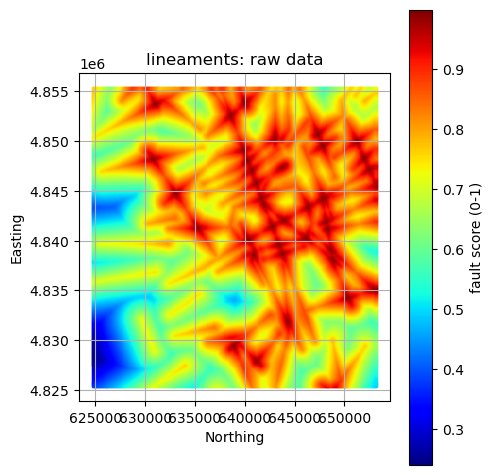

In [18]:
component = "reservoir"
layer = "lineaments"

# --- Fault processing for reservoir component ---
pfa = Processing.process_faults(
    pfa,
    criteria=criteria,
    component=component,
    layer=layer,
    extent=extent,
    nx=nx,
    ny=ny,
    alpha_fault=5500.0,        # decay distance for faults
    alpha_intersection=3500.0, # decay distance for intersections
    weight_fault=0.7,          # relative weighting of faults vs intersections
    weight_intersection=0.3,
    use_intersections=True,    # include intersection effects
)

#  Visualize the results
#  Note the plotted extent differs from the raw data when comparing

# Note we now grab the processed data from its "model" locations
gdf = pfa["criteria"][criteria]["components"][component]["layers"][layer]["model"]
col = pfa["criteria"][criteria]["components"][component]["layers"][layer]["model_data_col"]
units = pfa["criteria"][criteria]["components"][component]["layers"][layer]["model_units"]
title = f"{layer}: raw data"

GeospatialDataPlotters.geo_plot(gdf, col, units, title, markersize=2, figsize=(5, 5))

### Plot All Processed Layers

geologic
	heat


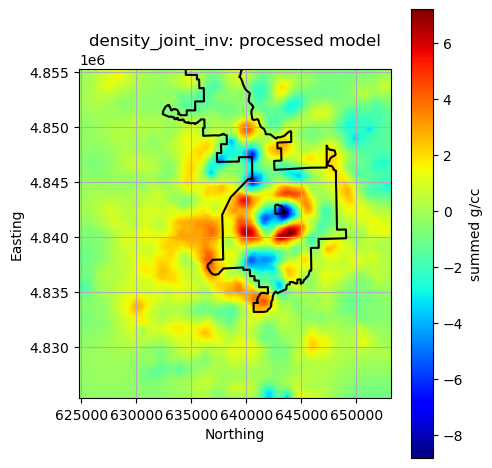

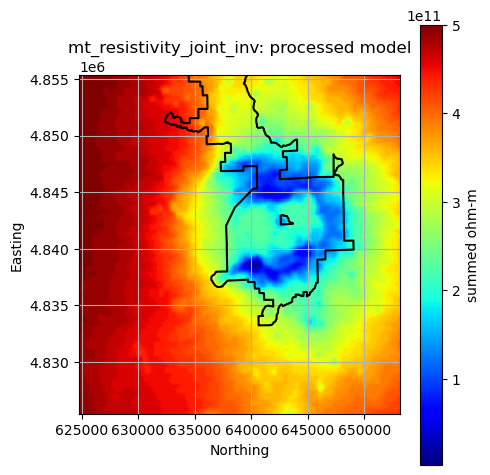

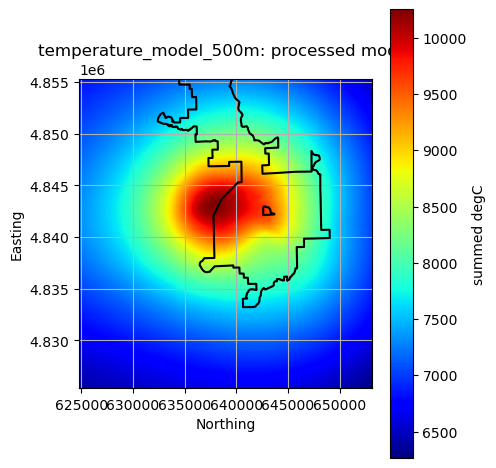

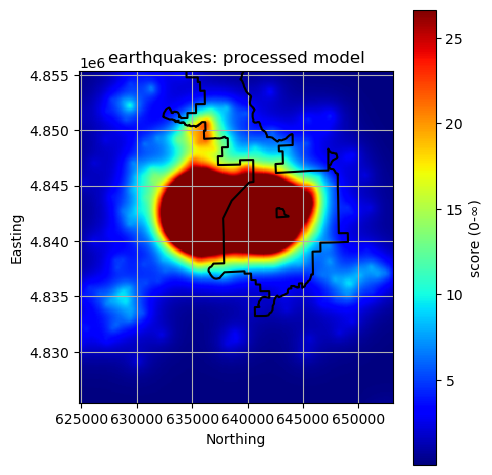

	reservoir


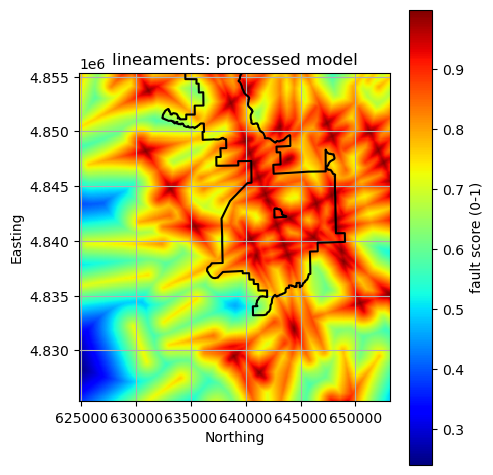

	insulation

Finished plotting all available processed layers.


In [19]:
for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    plotted_layers = []

    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")

        for layer, layer_data in comp_data["layers"].items():
            if layer in plotted_layers:
                continue

            # Skip if no processed model exists
            if "model" not in layer_data or layer_data["model"] is None:
                print(f"\t\t!! Skipping {layer}: no processed 'model' found.")
                continue

            gdf = layer_data["model"]
            col = layer_data.get("model_data_col")
            units = layer_data.get("model_units", "None")
            title = f"{layer}: processed model"

            # Plot in 3D
            GeospatialDataPlotters.geo_plot(
                gdf, col, units, title, area_outline=outline, extent=extent, markersize=0.75, figsize=(5, 5)
            )

            plotted_layers.append(layer)

print("\nFinished plotting all available processed layers.")

## Save Processed Layers
It’s good practice to save processed data to disk before proceeding so processing only has to be completed once. This allows the user to make minor tweaks to the PFA, such as adjusting weights, without reprocessing all data layers.

`geoPFA` has a built in function for this.

In [20]:
# Save processed CSV files to the same data directory
GeospatialDataWriters.save_processed_layers(pfa, data_dir)


Saving processed layers...

geologic
	heat
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\heat\density_joint_inv_processed.csv
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\heat\mt_resistivity_joint_inv_processed.csv
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\heat\temperature_model_500m_processed.csv
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\heat\earthquakes_processed.csv
	reservoir
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\reservoir\density_joint_inv_processed.csv
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\reservoir\mt_resistivity_joint_inv_processed.csv
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\reservoir\earthquakes_processed.csv
		Saved: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data\geologic\reservoir\lineaments_processed.csv
	insulation
		Saved: c:\Users\smello\code\geoPFA\exam

### Save a “Clean” PFA Config (no GeoDataFrames)
Similarly, saving a "clean" processed PFA config allows the user to avoid repeating the processing step when making minor adjustments to the PFA. This processed config serves as the config file for the next step. 

In [21]:
# Save clean processed PFA config file
GeospatialDataWriters.save_clean_pfa_config(
    pfa,
    config_dir / "newberry_superhot_processed_config.json"
)


Saving clean PFA configuration...

Processed PFA configuration saved to: c:\Users\smello\code\geoPFA\examples\Newberry\2D\config\newberry_superhot_processed_config.json



---

## Next Steps: Layer Combination and Favorability Modeling

This concludes **Notebook 1 – Data Processing with `geoPFA`**.

In this notebook, we:
- Loaded, cleaned, and standardized all input datasets  
- Processed each layer (filtering, interpolation, density, distance, transformations)  
- Saved the resulting **processed layers** to disk

You’re now ready to combine these layers into component and criteria favorability models.

If you skip running this notebook, don’t worry — the **supplementary example data** includes all intermediate processed files.  
You can start directly with **Notebook 2 – Layer Combination and Favorability Modeling**, which loads those preprocessed layers automatically.

